# `f0` vs `f0_raw_smoothing` — performance comparison

Both tables were generated by the same vectorbt backtest loop, only the signal
definition differs:

- `f0`: DEMA-style cross of two EMAs (`n1` fast vs `n2` slow).
- `f0_raw_smoothing`: single EMA (`n1`) plus a second EMA applied to the first
  (`smooth_period`). The second EMA acts as a smoother rather than a second
  trend line, so the long/short condition is `smoothed > ema1` (and vice versa).

All other knobs (`atr_period`, `sl_mult`, `rr_ratio`, `use_vwap`, `commission`,
`asset`, `timeframe`) are swept on the same grid. This notebook aggregates
each row in both tables and ranks the smoothing variant against the baseline.

In [4]:
import pandas as pd
import numpy as np
import sqlite3
from pathlib import Path

candidates = [
    Path.cwd() / 'backtest_results.db',
    Path.cwd().parent / 'backtest_results.db',
    Path.cwd().parent.parent / 'src' / 'backtest_results.db',
    Path('/home/chris/backtester/dema_strat/src/backtest_results.db'),
]
DB_PATH = next((p for p in candidates if p.exists()), None)
assert DB_PATH is not None, f'backtest_results.db not found in {candidates}'
print('using', DB_PATH)

con = sqlite3.connect(DB_PATH)
f0 = pd.read_sql('SELECT * FROM f0', con)
smooth = pd.read_sql('SELECT * FROM f0_raw_smoothing', con)
con.close()

print('f0 rows:', len(f0))
print('f0_raw_smoothing rows:', len(smooth))

using /home/chris/backtester/dema_strat/src/backtest_results.db
f0 rows: 8100
f0_raw_smoothing rows: 6750


In [4]:
metric_cols = ['expectancy', 'win_rate', 'max_dd', 'sharpe_ratio',
               'profit_factor', 'num_trades', 'return_pct']

def summary(df):
    return df[metric_cols].describe().T[['mean','std','min','50%','max']].round(4)

print('--- f0 summary ---')
print(summary(f0))
print()
print('--- f0_raw_smoothing summary ---')
print(summary(smooth))


--- f0 summary ---
                     mean          std        min         50%          max
expectancy        -0.0296       0.0017    -0.0329     -0.0298      -0.0207
win_rate          38.6019      12.3162    14.4588     35.5944      68.2823
max_dd             5.8711       7.5910     0.2910      2.2981      39.1535
sharpe_ratio     -40.0314      53.2064  -277.3967    -16.2420      -1.4230
profit_factor      0.5879       0.2087     0.1053      0.6343       0.8957
num_trades     96273.2399  124167.3502  5346.0000  39408.5000  641549.0000
return_pct        -5.8642       7.5955   -39.1535     -2.2948      -0.2229

--- f0_raw_smoothing summary ---
                     mean          std        min         50%          max
expectancy        -0.0275       0.0028    -0.0326     -0.0285      -0.0130
win_rate          45.2537      12.9495    15.0365     44.7327      68.3139
max_dd             5.1443       7.1723     0.1407      2.0118      36.5387
sharpe_ratio     -37.9510      50.9310  -267.35

In [4]:
key_cols = ['n1', 'atr_period', 'sl_mult', 'rr_ratio', 'use_vwap',
            'asset', 'timeframe']

f0_grouped = f0.groupby(key_cols, as_index=False)[metric_cols].mean()
smooth_grouped = smooth.groupby(key_cols, as_index=False)[metric_cols].mean()

merged = f0_grouped.merge(
    smooth_grouped, on=key_cols, suffixes=('_f0', '_smooth'))
print('aligned configs:', len(merged))

aligned configs: 1350


In [4]:
rows = []
for metric in metric_cols:
    a, b = f'{metric}_f0', f'{metric}_smooth'
    if metric == 'max_dd':
        wins = int((merged[b].abs() < merged[a].abs()).sum())
    else:
        wins = int((merged[b] > merged[a]).sum())
    delta_mean = (merged[b] - merged[a]).mean()
    delta_median = (merged[b] - merged[a]).median()
    rows.append({'metric': metric, 'smoothing_wins': wins,
                 'total': len(merged),
                 'mean_delta': round(delta_mean, 4),
                 'median_delta': round(delta_median, 4)})
print(pd.DataFrame(rows))


          metric  smoothing_wins  total  mean_delta  median_delta
0     expectancy            1186   1350      0.0021        0.0018
1       win_rate            1118   1350      6.6518        2.4545
2         max_dd             833   1350     -0.7268       -0.3297
3   sharpe_ratio             816   1350      2.0804        1.4141
4  profit_factor             372   1350     -0.0190       -0.0182
5     num_trades             536   1350  -6977.7363    -3300.3500
6     return_pct             833   1350      0.7242        0.3302


In [4]:
merged['expectancy_diff'] = merged['expectancy_smooth'] - merged['expectancy_f0']
merged['sharpe_diff']     = merged['sharpe_ratio_smooth'] - merged['sharpe_ratio_f0']
merged['return_diff']     = merged['return_pct_smooth'] - merged['return_pct_f0']
merged['maxdd_improve']   = merged['max_dd_f0'].abs() - merged['max_dd_smooth'].abs()
merged['pf_diff']         = merged['profit_factor_smooth'] - merged['profit_factor_f0']

print(merged[['expectancy_diff','sharpe_diff','return_diff','maxdd_improve','pf_diff']]
      .describe().T.round(4))


                  count    mean      std  ...     50%     75%      max
expectancy_diff  1350.0  0.0021   0.0022  ...  0.0018  0.0033   0.0111
sharpe_diff      1350.0  2.0804  11.1180  ...  1.4141  6.2016  48.3162
return_diff      1350.0  0.7242   2.2195  ...  0.3302  1.3407  10.9169
maxdd_improve    1350.0  0.7268   2.2183  ...  0.3297  1.3424  10.9169
pf_diff          1350.0 -0.0190   0.0409  ... -0.0182  0.0033   0.1087

[5 rows x 8 columns]


In [4]:
score = (merged['expectancy_diff'].rank(pct=True) +
         merged['sharpe_diff'].rank(pct=True) +
         merged['return_diff'].rank(pct=True) +
         merged['maxdd_improve'].rank(pct=True) +
         merged['pf_diff'].rank(pct=True)) / 5
merged['composite_score'] = score.round(4)

ranking = merged.sort_values('composite_score', ascending=False)
top = ranking[['timeframe','use_vwap','n1','atr_period','sl_mult','rr_ratio',
              'expectancy_f0','expectancy_smooth',
              'sharpe_ratio_f0','sharpe_ratio_smooth',
              'return_pct_f0','return_pct_smooth',
              'max_dd_f0','max_dd_smooth','composite_score']].head(15).round(4)
print('top 15 configs where smoothing variant beats DEMA cross:')
print(top)


top 15 configs where smoothing variant beats DEMA cross:
    timeframe  use_vwap  n1  ...  max_dd_f0  max_dd_smooth  composite_score
255        M1         1   5  ...     4.9997         2.9080           0.8884
165        M1         1   5  ...     4.9099         2.8859           0.8827
261        M1         1   5  ...     3.9835         2.1994           0.8797
75         M1         1   5  ...     4.7901         2.8406           0.8790
81         M1         1   5  ...     3.8713         2.1511           0.8769
267        M1         1   5  ...     3.4661         1.8074           0.8766
87         M1         1   5  ...     3.3960         1.7673           0.8753
171        M1         1   5  ...     3.9294         2.1878           0.8750
177        M1         1   5  ...     3.4338         1.7972           0.8736
525        M1         1   7  ...     4.7966         2.8543           0.8679
69         M1         1   5  ...     7.2563         4.3955           0.8670
249        M1         1   5  ..

In [4]:
by_tf = merged.groupby('timeframe').agg(
    f0_expectancy=('expectancy_f0','mean'),
    smooth_expectancy=('expectancy_smooth','mean'),
    f0_sharpe=('sharpe_ratio_f0','mean'),
    smooth_sharpe=('sharpe_ratio_smooth','mean'),
    f0_return=('return_pct_f0','mean'),
    smooth_return=('return_pct_smooth','mean'),
    f0_maxdd=('max_dd_f0', lambda s: s.abs().mean()),
    smooth_maxdd=('max_dd_smooth', lambda s: s.abs().mean()),
    wins_expectancy=('expectancy_diff', lambda s: int((s>0).sum())),
    n=('expectancy_diff','size'),
).round(4)
print(by_tf)


           f0_expectancy  smooth_expectancy  ...  wins_expectancy    n
timeframe                                    ...                      
M1               -0.0310            -0.0286  ...              450  450
M15              -0.0281            -0.0263  ...              289  450
M5               -0.0296            -0.0276  ...              447  450

[3 rows x 10 columns]


In [4]:
print(smooth.groupby('smooth_period')[metric_cols].mean().round(4))


               expectancy  win_rate  ...  num_trades  return_pct
smooth_period                        ...                        
6                 -0.0273   45.1410  ...  96362.6163     -5.5292
8                 -0.0273   45.2442  ...  91676.4822     -5.2675
10                -0.0274   45.2946  ...  88432.3185     -5.0872
12                -0.0276   45.3064  ...  85982.4807     -4.9576
14                -0.0279   45.2824  ...  84023.6200     -4.8583

[5 rows x 7 columns]


In [4]:
n = len(merged)
print(f'Configs where smoothing beats DEMA cross on expectancy: '
      f'{(merged["expectancy_diff"] > 0).sum()}/{n}')
print(f'Configs where smoothing beats DEMA cross on Sharpe:     '
      f'{(merged["sharpe_diff"] > 0).sum()}/{n}')
print(f'Configs where smoothing has shallower drawdown:         '
      f'{(merged["maxdd_improve"] > 0).sum()}/{n}')
print(f'Configs where smoothing has higher return %:            '
      f'{(merged["return_diff"] > 0).sum()}/{n}')
print(f'Configs where smoothing has higher profit factor:       '
      f'{(merged["pf_diff"] > 0).sum()}/{n}')

Configs where smoothing beats DEMA cross on expectancy: 1186/1350
Configs where smoothing beats DEMA cross on Sharpe:     816/1350
Configs where smoothing has shallower drawdown:         833/1350
Configs where smoothing has higher return %:            833/1350
Configs where smoothing has higher profit factor:       372/1350


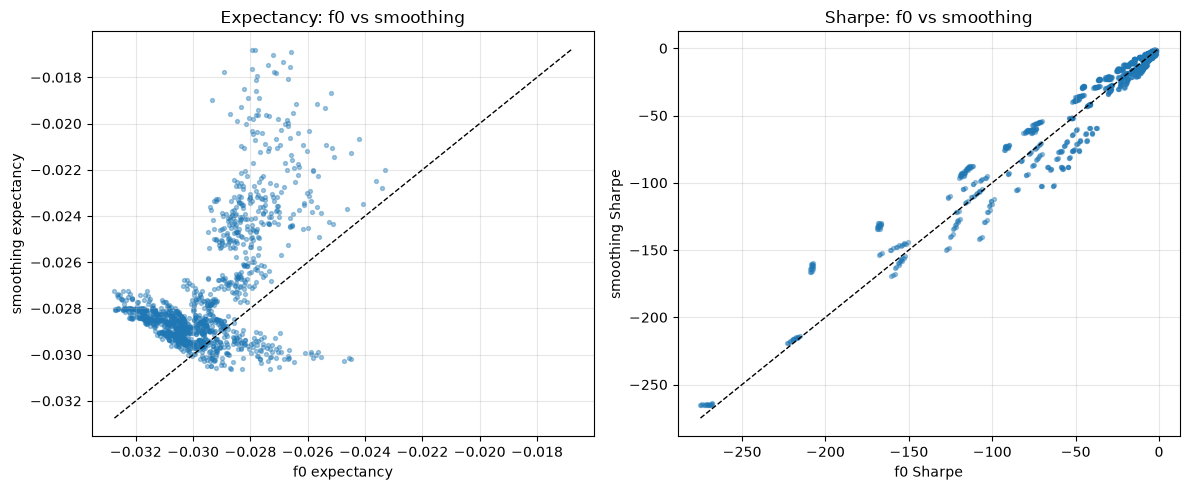

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(merged['expectancy_f0'], merged['expectancy_smooth'],
                s=8, alpha=0.4)
lims = [min(merged['expectancy_f0'].min(), merged['expectancy_smooth'].min()),
        max(merged['expectancy_f0'].max(), merged['expectancy_smooth'].max())]
axes[0].plot(lims, lims, 'k--', lw=1)
axes[0].set_xlabel('f0 expectancy')
axes[0].set_ylabel('smoothing expectancy')
axes[0].set_title('Expectancy: f0 vs smoothing')
axes[0].grid(alpha=0.3)

axes[1].scatter(merged['sharpe_ratio_f0'], merged['sharpe_ratio_smooth'],
                s=8, alpha=0.4)
lims = [min(merged['sharpe_ratio_f0'].min(), merged['sharpe_ratio_smooth'].min()),
        max(merged['sharpe_ratio_f0'].max(), merged['sharpe_ratio_smooth'].max())]
axes[1].plot(lims, lims, 'k--', lw=1)
axes[1].set_xlabel('f0 Sharpe')
axes[1].set_ylabel('smoothing Sharpe')
axes[1].set_title('Sharpe: f0 vs smoothing')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()